In [1]:
import os
from rdkit import Chem, RDConfig
from rdkit.Chem.EState.EState_VSA import EState_VSA9
from torch_geometric.data import Data, Dataset
from rdkit.Chem import Crippen, rdPartialCharges, ChemicalFeatures, MolFromSmiles, MolSurf, Descriptors, rdMolDescriptors, Lipinski
import copy
from os import walk
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch_geometric.nn import MessagePassing, global_add_pool
from torch_geometric.loader import DataLoader
from data_visualsation.plot_matplotlib import plot

# Graph building

### Molecular Graph Construction Utilities

This module provides functions to convert molecular structures (SMILES) into graph representations suitable for graph neural networks (GNNs) using RDKit and PyTorch Geometric.

Converts a molecule into a PyTorch Geometric `Data` object with:

**Node Features (Atom-Level):**
- Explicit valence
- Aromaticity
- Hybridization type (SP/SP²/SP³)
- Covalent radius
- Atomic weight
- Outer electrons
- Sanderson electronegativity
- Crippen logP contribution
- Gasteiger charge
- Formal charge
- Donor/acceptor flags

**Edge Features (Bond-Level):**
- Aromaticity
- Bond type (as double)
- Conjugation status
- Ring membership

**Molecule-Level Attributes (Optional):**
- Crippen logP/MR
- VSA descriptors
- TPSA
- Labute ASA
- Lipinski donor/acceptor counts
- Morgan fingerprint density

#### Features:
- **Automatic Normalization**: L2-normalizes node/edge features by column
- **Bidirectional Edges**: Creates reverse edges (k→j) for every bond (j→k)
- **Flexible Output**: Optional edge attributes and global molecular features
- **Dataset Integration**: `MoleculeGraphDataset` class for batch processing

In [ ]:
def normalize(tensor, orientation='column'):
    if orientation == 'column':
        return torch.nn.functional.normalize(tensor.T).T
    else:
        return torch.nn.functional.normalize(tensor)

def get_atoms_attr_tensor(mol):
    def get_atoms_properties_list(mol):
        mol = Chem.AddHs(mol)
        Chem.SanitizeMol(mol)
        rdPartialCharges.ComputeGasteigerCharges(mol)

        Crippen._GetAtomContribs(mol)
        rdPartialCharges.ComputeGasteigerCharges(mol)
        fdef = ChemicalFeatures.BuildFeatureFactory(os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef'))
        features = fdef.GetFeaturesForMol(mol)
        donors = set()
        acceptors = set()

        for feat in features:
            if feat.GetFamily() == 'Donor':
                donors.update(feat.GetAtomIds())
            elif feat.GetFamily() == 'Acceptor':
                acceptors.update(feat.GetAtomIds())

        def get_electronegativity(atom_num):
            electronegativity_Sanderson_dict = {1: 2.592,
                                                5: 2.275,
                                                6: 2.746,
                                                7: 3.194,
                                                8: 3.654,
                                                9: 4.000,
                                                14: 2.138,
                                                15: 2.515,
                                                16: 2.957,
                                                17: 3.475,
                                                35: 3.219,
                                                53: 2.778}
            return electronegativity_Sanderson_dict.get(atom_num, 0)

        hybrid_dict = {
            Chem.rdchem.HybridizationType.S: [1, 0, 0, 0],
            Chem.rdchem.HybridizationType.SP: [0, 1, 0, 0],
            Chem.rdchem.HybridizationType.SP2: [0, 0, 1, 0],
            Chem.rdchem.HybridizationType.SP3: [0, 0, 0, 1]
        }

        pt = Chem.GetPeriodicTable()
        crippen_contribs = Crippen._GetAtomContribs(mol)
        atom_properties_list = []

        for atom in mol.GetAtoms():
            if atom.GetAtomicNum() == 1:
                continue
            properties = []
            properties.append(atom.GetExplicitValence())
            properties.append(1 if atom.GetIsAromatic() else 0)
            properties.extend(hybrid_dict.get(atom.GetHybridization(), [0, 0, 0, 0]))
            properties.append(pt.GetRcovalent(atom.GetAtomicNum()))
            properties.append(pt.GetAtomicWeight(atom.GetAtomicNum()))
            properties.append(pt.GetNOuterElecs(atom.GetAtomicNum()))
            properties.append(get_electronegativity(atom.GetAtomicNum()))
            properties.append(crippen_contribs[atom.GetIdx()][0])

            gasteiger_charge = 0.0
            if atom.HasProp('_GasteigerCharge'):
                charge_str = atom.GetProp('_GasteigerCharge')
                try:
                    gasteiger_charge = float(charge_str)
                    if np.isnan(gasteiger_charge):
                        gasteiger_charge = 0.0
                except ValueError:
                    gasteiger_charge = 0.0
            properties.append(gasteiger_charge)

            properties.append(atom.GetFormalCharge())
            properties.append(1 if atom.GetIdx() in donors else 0)
            properties.append(1 if atom.GetIdx() in acceptors else 0)
            atom_properties_list.append(properties)

        return atom_properties_list

    atoms_properties_list = get_atoms_properties_list(mol)
    atoms_properties_tensor = torch.tensor(atoms_properties_list, dtype=torch.float32)
    return atoms_properties_tensor

def get_bonds_list(mol):
    bonds = mol.GetBonds()

    bonds_list = []
    for bond in bonds:
        bonds_list.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])

    return bonds_list

def get_bonds_attr_tensor(mol, bonds_list):
    bonds_properties_list = []

    for i, (j, k) in enumerate(bonds_list):
        properties = []

        bond = mol.GetBondBetweenAtoms(j, k)

        properties.append(bond.GetIsAromatic())
        properties.append(bond.GetBondTypeAsDouble())
        properties.append(1 if bond.GetIsConjugated() else 0)
        properties.append(1 if bond.IsInRing() else 0)

        bonds_properties_list.append(properties)

    bonds_attr_x_tensor = torch.tensor(bonds_properties_list, dtype=torch.float32)

    return bonds_attr_x_tensor

def get_molecule_attr_tensor(mol):
    molecule_attr_list = []

    molecule_attr_list.append(Crippen.MolLogP(mol))
    molecule_attr_list.append(MolSurf.PEOE_VSA6(mol))
    molecule_attr_list.append(Descriptors.FpDensityMorgan1(mol))
    molecule_attr_list.append(Crippen.MolMR(mol))
    molecule_attr_list.append(EState_VSA9(mol))
    molecule_attr_list.append(rdMolDescriptors.CalcLabuteASA(mol))
    molecule_attr_list.append(Lipinski.NumHDonors(mol))
    molecule_attr_list.append(Lipinski.NumHAcceptors(mol))
    molecule_attr_list.append(rdMolDescriptors.CalcTPSA(mol))
    molecule_attr_list.append(rdMolDescriptors.CalcChi0v(mol))

    return torch.tensor(molecule_attr_list, dtype=torch.float32)

def build_graph_data(mol, y=None, add_edge_attr=True, add_molecule_attr=True):
    atoms_attr_tensor = get_atoms_attr_tensor(mol)
    atoms_attr_tensor_norm = normalize(atoms_attr_tensor)

    bonds_list = get_bonds_list(mol)
    edges_attr_x_tensor = get_bonds_attr_tensor(mol, bonds_list)
    edges_attr_x_tensor_norm = normalize(edges_attr_x_tensor)

    edge_index = []
    edge_attr = []

    for i, (j, k) in enumerate(bonds_list):
        edge_index.append([j, k])
        edge_attr.append(edges_attr_x_tensor_norm[i])

        edge_index.append([k, j])
        edge_attr.append(edges_attr_x_tensor_norm[i])

    edge_index_tensor = torch.tensor(edge_index, dtype=torch.int64).T

    data_dict = {
        'x': atoms_attr_tensor_norm,
        'edge_index': edge_index_tensor,
    }

    if add_edge_attr:
        edge_attr_tensor = torch.stack(edge_attr)
        data_dict['edge_attr'] = edge_attr_tensor

    if add_molecule_attr:
        molecule_attr_tensor = get_molecule_attr_tensor(mol)
        data_dict['molecule_attr'] = molecule_attr_tensor

    if y is not None:
        y_tensor = torch.tensor([y], dtype=torch.float32)
        data_dict['y'] = y_tensor

    return Data(**data_dict)

# Creating of train dataset

In [ ]:
data_train = pd.read_csv(r'C:\Users\AI1-PC\PycharmProjects\main\GNN_test\datasets\data_train.csv')
train_smiles = data_train.iloc[:, 0].to_numpy()
train_LogP = data_train.iloc[:, 1].to_numpy()
for i in range(len(train_smiles)):
    mol = MolFromSmiles(train_smiles[i])
    data = build_graph_data(mol, train_LogP[i])
    torch.save(data, fr'C:\Users\AI1-PC\PycharmProjects\main\GNN_test\datasets\graph_database_train\{i}.pt')

# GNN initialization and training

### Directed Message Passing Neural Network (DMPNN) for Molecular Property Prediction

#### Architecture Overview
**DMPNN Model** (`DMPNNModel`) implements a graph neural network for molecular regression tasks (e.g., logP prediction) with:

1. **Input Processing**:
   - Atom feature embedding (15D → 80D)
   - Edge-aware message passing
   - Molecule-level descriptor integration

2. **Core Components**:
   - **Stacked DMPNN Layers** (3 layers):
     - Message function: `MLP([hidden_dim + edge_dim] → hidden_dim)`
     - Update function: Residual connection + LayerNorm
   - **Global Pooling**: Sum aggregation over molecular graph
   - **Multi-modal Fusion**: Concatenates graph representation with normalized molecular descriptors

3. **Output Head**:
   - 2-layer MLP with GELU activation
   - Final bias correction term
   - Dropout (50%) for regularization

#### Key Features
- **Edge-Attentive Processing**: Utilizes bond attributes (aromaticity, conjugation) in message passing
- **Descriptor Hybridization**: Combines learned graph features with engineered molecular properties (10 → 64D)
- **Stability Enhancements**:
  - Layer normalization after each MP step
  - AdamW optimizer with weight decay (0.001)
  - Early stopping (patience=20 epochs)
  - Standard scaling of molecular descriptors


In [2]:
def normalize_molecule_attr(data_list):
    molecule_attrs = np.array([data.molecule_attr.numpy() for data in data_list])
    scaler = StandardScaler()
    scaler.fit(molecule_attrs)
    for data in data_list:
        data.molecule_attr = torch.tensor(scaler.transform(data.molecule_attr.numpy().reshape(1, -1)), dtype=torch.float32)
    return scaler

def load_dataset(name):
    directory = r'C:\Users\AI1-PC\PycharmProjects\main\datasets\logP'
    data_list = []

    if name == 'train':
        path = r'\graph_database_train_cut_mol_attr_no_dub_mean'
    elif name == 'test':
        path = r'\graph_database_test_mol_attr'
    else:
        raise ValueError("Invalid dataset name")

    directory += path

    file_names = next(walk(directory), (None, None, []))[2]

    for file_name in file_names:
        file_path = directory + fr'\{file_name}'
        tensor = torch.load(file_path, weights_only=False)
        data_list.append(tensor)

    return data_list

class DMPNNLayer(MessagePassing):
    def __init__(self, input_node_dim, edge_dim, hidden_dim):
        super(DMPNNLayer, self).__init__(aggr='add')


        self.input_node_dim = input_node_dim
        self.edge_dim = edge_dim
        self.hidden_dim = hidden_dim

        self.node_transform = nn.Linear(input_node_dim, hidden_dim)
        self.edge_transform = nn.Linear(edge_dim, hidden_dim)

        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr):
        x_transformed = self.node_transform(x)
        edge_attr_transformed = self.edge_transform(edge_attr)

        return self.propagate(edge_index, x=x_transformed, edge_attr=edge_attr_transformed)

    def message(self, x_j, edge_attr):
        message_input = torch.cat([x_j, edge_attr], dim=-1)
        return self.message_mlp(message_input)

    def update(self, aggr_out, x):
        update_input = torch.cat([aggr_out, x], dim=-1)
        return self.update_mlp(update_input)

class DMPNNModel(nn.Module):

    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers):
        super(DMPNNModel, self).__init__()
        self.num_layers = num_layers

        self.node_embedding = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        self.mpnn_layers = nn.ModuleList([
            nn.ModuleDict({
                'layer': DMPNNLayer(hidden_dim, edge_dim, hidden_dim),
                'norm': nn.LayerNorm(hidden_dim),
            }) for _ in range(num_layers)
        ])

        self.fc_molecule_attr = nn.Sequential(
            nn.Linear(10, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )


        self.fc_final = nn.Sequential(
            nn.Linear(hidden_dim + 64, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(256, 1, bias=True)
        )

        self.bias_correction = nn.Parameter(torch.zeros(1))


    def forward(self, data):
        x, edge_index, edge_attr, molecule_attr, batch = data.x, data.edge_index, data.edge_attr, data.molecule_attr, data.batch
        x = self.node_embedding(x)

        for layer in self.mpnn_layers:
            res = x
            x = layer['layer'](x, edge_index, edge_attr)
            x = x + res
            x = layer['norm'](x)

        graph_representation = global_add_pool(x, batch)

        molecule_attr = molecule_attr.view(-1, 10)
        molecule_attr = self.fc_molecule_attr(molecule_attr)

        final_cat = torch.cat((graph_representation, molecule_attr), dim=1)

        out = self.fc_final(final_cat)
        return out

train_data_list = load_dataset('train')
train_data_list, val_data_list = train_test_split(train_data_list, train_size=0.8, random_state=42)

hidden_dim = 80
num_layers = 3

num_epochs = 200
batch_size = 80

patience = 20
patience_counter = 0

model = DMPNNModel(node_dim=15, edge_dim=4, hidden_dim=hidden_dim, num_layers=num_layers).to('cuda')

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00055, weight_decay=0.001, foreach=True)

train_loader = DataLoader(train_data_list, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data_list, batch_size=batch_size, shuffle=False, pin_memory=True)

best_test_loss = float('inf')
train_losses = []
test_losses = []
best_state_dict = None

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        batch = batch.to('cuda')
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch.y.view(-1, 1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch.num_graphs

    train_loss_epoch = running_loss / len(train_data_list)
    train_losses.append(train_loss_epoch)

    model.eval()
    test_loss_running = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to('cuda')
            outputs = model(batch)
            loss = torch.sqrt(criterion(outputs, batch.y.view(-1, 1)))
            test_loss_running += loss.item() * batch.num_graphs

    test_loss_epoch = test_loss_running / len(val_data_list)
    test_losses.append(test_loss_epoch)

    print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss_epoch:.4f} | Test Loss: {test_loss_epoch:.4f}')

    if test_loss_epoch < best_test_loss:
        best_test_loss = test_loss_epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_state_dict)

Epoch 1/200 | Train Loss: 2.5697 | Test Loss: 1.1968
Epoch 2/200 | Train Loss: 1.3547 | Test Loss: 1.0442
Epoch 3/200 | Train Loss: 1.2195 | Test Loss: 0.9171
Epoch 4/200 | Train Loss: 1.1555 | Test Loss: 0.9679
Epoch 5/200 | Train Loss: 1.0822 | Test Loss: 0.9021
Epoch 6/200 | Train Loss: 1.0581 | Test Loss: 1.0380
Epoch 7/200 | Train Loss: 1.0128 | Test Loss: 0.9299
Epoch 8/200 | Train Loss: 1.0107 | Test Loss: 0.9665
Epoch 9/200 | Train Loss: 0.9788 | Test Loss: 0.9048
Epoch 10/200 | Train Loss: 0.9542 | Test Loss: 0.9042
Epoch 11/200 | Train Loss: 0.9408 | Test Loss: 0.8821
Epoch 12/200 | Train Loss: 0.9290 | Test Loss: 0.9163
Epoch 13/200 | Train Loss: 0.9332 | Test Loss: 0.9075
Epoch 14/200 | Train Loss: 0.9328 | Test Loss: 0.8537
Epoch 15/200 | Train Loss: 0.8876 | Test Loss: 0.8324
Epoch 16/200 | Train Loss: 0.8838 | Test Loss: 0.8423
Epoch 17/200 | Train Loss: 0.8760 | Test Loss: 0.8619
Epoch 18/200 | Train Loss: 0.8637 | Test Loss: 0.9713
Epoch 19/200 | Train Loss: 0.8371 | T

<All keys matched successfully>

# Learning curve

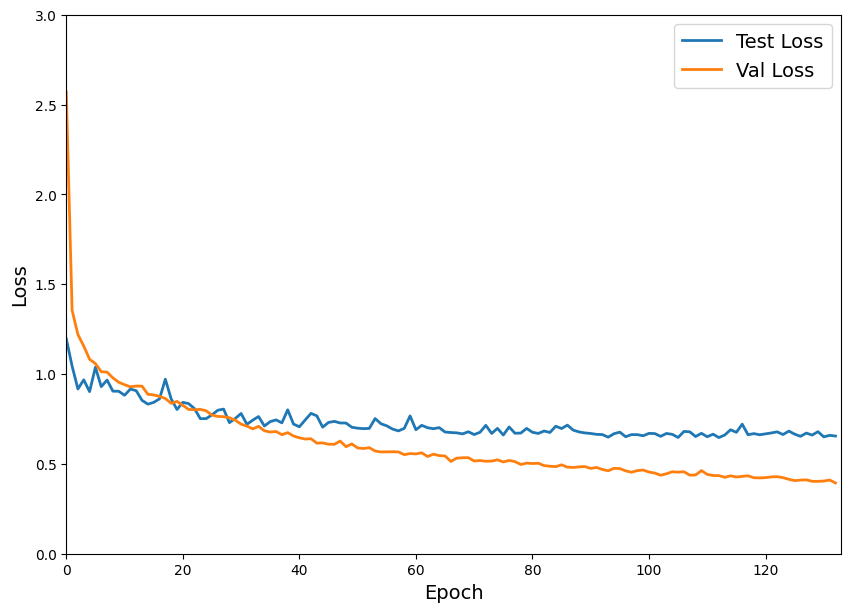

In [10]:
plt.figure(figsize=(10, 7))
plt.plot(range(epoch+1), test_losses, label='Test Loss', linewidth=2)
plt.plot(range(epoch+1), train_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.ylim(0, 3)
plt.xlim(0, epoch+1)
plt.legend(fontsize=14)
plt.show()

# GNN evaluation graphs

R² Train: 0.9072
R² Test: 0.8727


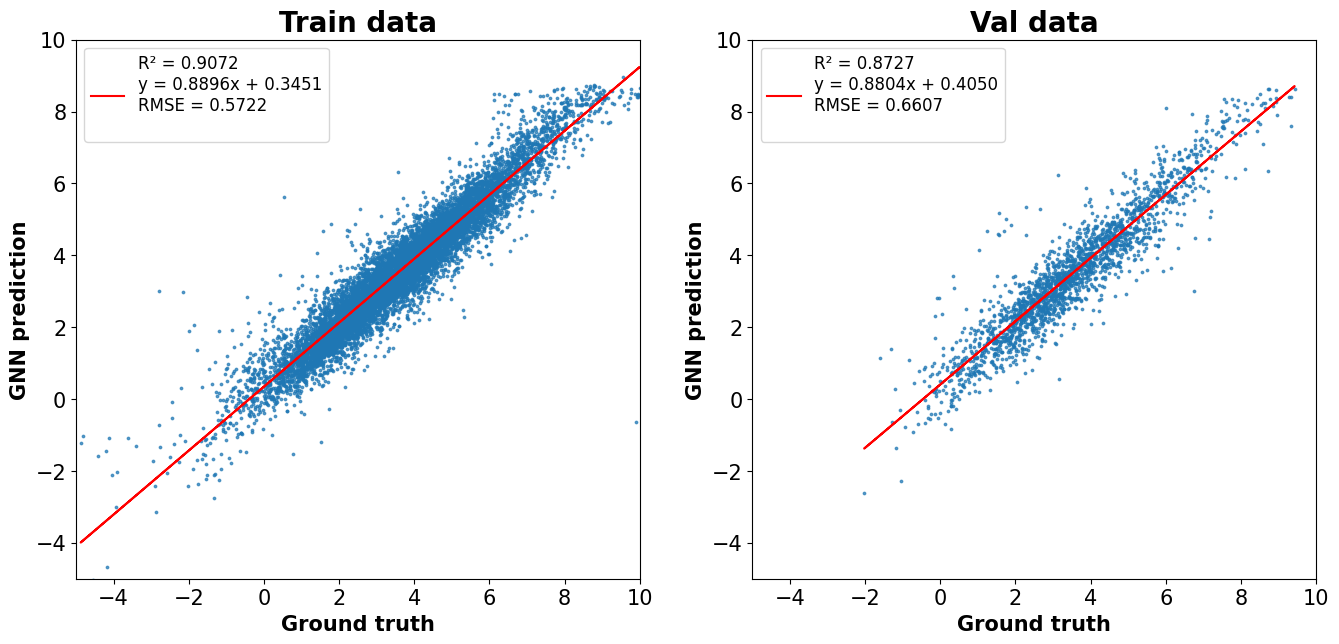

In [5]:
model.eval()

y_train_pred = []
y_train_true = []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to('cuda')
        outputs = model(batch)
        y_train_pred.extend(outputs.cpu().numpy().flatten())
        y_train_true.extend(batch.y.cpu().numpy().flatten())

y_val_pred = []
y_val_true = []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to('cuda')
        outputs = model(batch)
        y_val_pred.extend(outputs.cpu().numpy().flatten())
        y_val_true.extend(batch.y.cpu().numpy().flatten())

y_train_pred = np.array(y_train_pred)
y_val_pred = np.array(y_val_pred)
y_train_true = np.array(y_train_true)
y_val_true = np.array(y_val_true)

r2_train = r2_score(y_train_true, y_train_pred)
r2_val = r2_score(y_val_true, y_val_pred)

print(f'R² Train: {r2_train:.4f}')
print(f'R² Val: {r2_val:.4f}')

plot(y_val_true, y_val_pred, y_train_true, y_train_pred, axis_lims=[-5, 10, -5, 10])